In [1]:
import sys
import numpy as np
import torch 
# still do preprocessing in scipy
import scipy.sparse as sp
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from importlib import reload
# get UMAP
import umap
from tqdm import tqdm
import pandas as pd

# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor')
import factor_model
reload(factor_model)

import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style='white', context='notebook', rc={'figure.figsize':(6,6)}, font_scale=1.5)

2.2.1+cu118
11.8
2.2.1+cu118
11.8


In [2]:
# Append this directory to sys.path
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/clustering/')
import load_cluster_data as llc 

# Append also simulation directory
sys.path.append("/gpfs/commons/home/kisaev/Leaflet-private/src/simulation/")
import simulate_counts as sim 
reload (sim)

<module 'simulate_counts' from '/gpfs/commons/home/kisaev/Leaflet-private/src/simulation/simulate_counts.py'>

### Settings

In [3]:
torch.manual_seed(42)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

cpu


### Load junction and intron cluster counts

In [4]:
# let's simulate using the mammary gland data
input_files_folder = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/model_input/Mammary_Gland/"

# convert data to Leaflet required input formats 
final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = llc.load_cluster_data(
    input_folder = input_files_folder, max_intron_count=5000, remove_singletons=True, has_genes="yes") 

# add cluster to final_data 
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index"], how="left")

# get indices (maybe don't need this actually)
indices = (final_data.cell_id_index, final_data.junction_id_index)
indices_np = np.stack(indices)
junc_counts = sp.coo_matrix((final_data.junc_count, indices))
cluster_counts = sp.coo_matrix((final_data.cluster_count, indices))

Reading in data from folder ...
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/model_input/Mammary_Gland/
Finished reading in data from folder ...
Removing singletons ...
Number of junctions before removing singletons:  157665
Number of junctions after removing singletons:  47015
The number of unique cell types in the data is:  4
The number of unique cells in the data is:  2405
The number of unique junctions in the data is:  47016
The maximum junction count was initially:  251545
375
The maximum junction count is now:  4999
The number of junctions in the data is:  44087
The number of cells in the data is:  2405
The number of cell types in the data is:  4


In [5]:
# double check which cell types are present
cell_ids_conversion.cell_type.value_counts()

cell_type
Mammary_Gland_basal_cell                                  1340
Mammary_Gland_luminal_epithelial_cell_of_mammary_gland     578
Mammary_Gland_stromal_cell                                 440
Mammary_Gland_endothelial_cell                              47
Name: count, dtype: int64

In [6]:
# sanity check that counts are saved in correct indices in sparse matrices
ind_random = np.random.randint(0, len(final_data))
print(final_data.iloc[ind_random])
print(junc_counts.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].junction_id_index])
print(cluster_counts.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].junction_id_index])

cell_id_index                                                   1241
junction_id_index                                              18555
junc_count                                                       1.0
cluster_count                                                      2
clustminjunc                                                     1.0
juncratio                                                        0.5
cell_id              I21-B002435-3_39_F-1-1_Mammary_Gland_basal_cell
cell_type                                   Mammary_Gland_basal_cell
junction_id                                      8_40908195_40910994
Cluster                                                        55567
gene_id                                                       Slc7a2
Name: 12788222, dtype: object
1.0
2


### For simulating data, let's only keep clusters that have exon skipping event, so cluster with three junctions 

In [7]:
# SS are shared between end of J1 and start of J2 and end of J2 and start of J3
junc_info = junction_ids_conversion[["junction_id", "Cluster", "junction_id_index"]].drop_duplicates()

# get number of junctions in each cluster first 
cluster_junc_counts = junc_info.groupby(["Cluster"]).agg({"junction_id": "count"}).reset_index()
clusts_keep = cluster_junc_counts[cluster_junc_counts["junction_id"] == 3 ]
junc_info = junc_info[junc_info["Cluster"].isin(clusts_keep["Cluster"])]

# break up junction_id column in junc_info into chr, start and end 
junc_info["chr"] = junc_info["junction_id"].str.split("_").str[0]
junc_info["start"] = junc_info["junction_id"].str.split("_").str[1]
junc_info["end"] = junc_info["junction_id"].str.split("_").str[2]
print(len(junc_info["Cluster"].unique()))

6594


In [8]:
# run function on all clusters to find simple exon skipping events 
clusters_SS = []

for cluster in tqdm(junc_info["Cluster"].unique()): # this is very slow
    clusters_SS.append(sim.check_SS_cluster(final_data, junc_info, cluster))

# keep only entries in clusters_SS that are not None 
clusters_SS = [x for x in clusters_SS if x is not None]
print(len(clusters_SS))

# get indices of junctions in clusters_SS (original indices before filtering)
junc_ind_keep = junction_ids_conversion[junction_ids_conversion["Cluster"].isin(clusters_SS)]["junction_id_index"]
print(len(junc_ind_keep))
final_data = final_data[final_data.junction_id_index.isin(junc_ind_keep)] #using original junction id index

# filter junction_ids file to only include junctions in clusters_SS
junction_ids_conversion = junction_ids_conversion[junction_ids_conversion["junction_id_index"].isin(junc_ind_keep)]
# reset index of junction_ids_conversion and make a new column new_junction_id_index
junction_ids_conversion = junction_ids_conversion.reset_index(drop=True)
# re-order junction_ids_conversion junction_id_index
junction_ids_conversion = junction_ids_conversion.sort_values(by=['junction_id_index'])
junction_ids_conversion["new_junction_id_index"] = junction_ids_conversion.index
print(junction_ids_conversion.head())

# re-order the remaining junctions and subset the counts matrices
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index", "Cluster", "junction_id"])

# where is new_junction_id_index coming from here? 
final_data.sort_values(by = ["new_junction_id_index"], inplace = True)
final_data.head()

to_keep = final_data["junction_id_index"].unique()   # use original junction indices to filter out the count matrices 
junc_counts_sub = junc_counts.tocsr()[:,to_keep].tocoo()
cluster_counts_sub = cluster_counts.tocsr()[:,to_keep].tocoo()

100%|██████████| 6594/6594 [03:32<00:00, 30.99it/s]


6388
19164
   junction_id_index          junction_id  Cluster gene_id  \
0                 12  1_78692220_78694195      114   Acsl3   
1                 13  1_78694346_78696080      114   Acsl3   
2                 20  1_74236899_74246079      344   Arpc2   
3                 21  1_74246114_74248131      344   Arpc2   
4                 22  1_74255014_74255957      347   Arpc2   

   new_junction_id_index  
0                      0  
1                      1  
2                      2  
3                      3  
4                      4  


In [9]:
# sanity check that counts are saved in correct indices in sparse matrices
ind_random = np.random.randint(0, len(final_data))
print(final_data.iloc[ind_random])
print(junc_counts_sub.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].new_junction_id_index])
print(cluster_counts_sub.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].new_junction_id_index])

cell_id_index                                                        586
junction_id_index                                                   4029
junc_count                                                           5.0
cluster_count                                                          8
clustminjunc                                                         3.0
juncratio                                                          0.625
cell_id                  E16-B000166-3_56_F-1-1_Mammary_Gland_basal_cell
cell_type                                       Mammary_Gland_basal_cell
junction_id                                         11_58988929_58990186
Cluster                                                            77119
gene_id_x                                                         Trim11
gene_id_y                                                         Trim11
new_junction_id_index                                               1807
Name: 2342995, dtype: object
5.0
8


<Axes: xlabel='juncratio', ylabel='Count'>

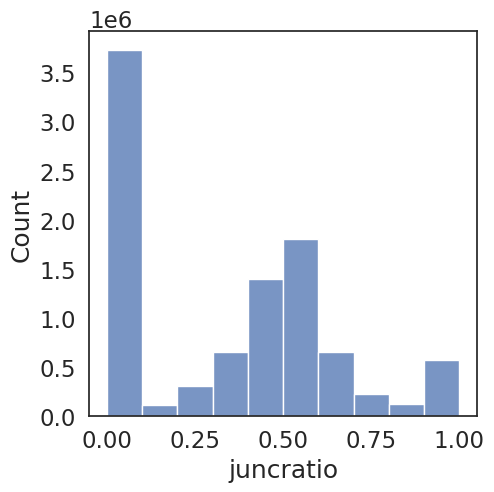

In [10]:
# set figure size to be small
plt.figure(figsize=(5,5))
sns.histplot(final_data.juncratio, bins=10)

### Let's simulate some data!

In [11]:
# update junc_info to only include junctions in clusters_SS
junc_info = junc_info[junc_info["Cluster"].isin(clusters_SS)]
junc_info = junc_info.reset_index(drop=True)
junc_info["new_junction_id_index"] = junc_info.index
junc_info.head()

,junction_id,Cluster,junction_id_index,chr,start,end,new_junction_id_index
0,1_78692220_78694195,114,12,1,78692220,78694195,0
1,1_78694346_78696080,114,13,1,78694346,78696080,1
2,1_74236899_74246079,344,20,1,74236899,74246079,2
3,1_74246114_74248131,344,21,1,74246114,74248131,3
4,1_74255014_74255957,347,22,1,74255014,74255957,4


In [12]:
cell_ids_conversion.cell_type.value_counts()

cell_type
Mammary_Gland_basal_cell                                  1340
Mammary_Gland_luminal_epithelial_cell_of_mammary_gland     578
Mammary_Gland_stromal_cell                                 440
Mammary_Gland_endothelial_cell                              47
Name: count, dtype: int64

In [13]:
print(len(junc_info.junction_id.unique()))
print(len(junc_info.Cluster.unique()))

19164
6388


In [14]:
simulated_counts, cell_types, cell_type_psi, cluster_labels = sim.simulate_junc_counts(cluster_counts_sub, junc_info, cell_types=cell_ids_conversion.cell_type.astype('category'))

Using pre-defined cell types!
The number of cell types is: 4
The number of cells is: 2405
The number of junctions is: 19164


100%|██████████| 6388/6388 [00:20<00:00, 307.42it/s]


The columns to keep are: Index([0, 1, 2, 3], dtype='object')
Done simulating PSI!
Done simulating junc counts!


In [15]:
# save simulated counts, cell types and psi values
sim_juncs_counts = simulated_counts
cell_type_psi_df = cluster_labels

In [16]:
# get variance in simulated psi values across all simulated cell types 
K = len(np.unique(cell_types))
print(K)

4


In [17]:
# make column difference which calculates the variance across colujmns 0:K
cell_type_psi_df["difference"] = cell_type_psi_df.iloc[:, 0:K].var(axis=1)
cell_type_psi_df.head()

,0,1,2,3,new_junction_id_index,sample_label,Cluster,difference
0,0.081535,0.155184,0.049865,0.265594,0,positive,114,0.009177
2,0.081535,0.155184,0.049865,0.265594,1,positive,114,0.009177
0,0.216247,0.474011,0.314983,0.118132,2,positive,344,0.023042
2,0.216247,0.474011,0.314983,0.118132,3,positive,344,0.023042
0,0.106546,0.106546,0.106546,0.106546,4,negative,347,0.000000


In [18]:
# label anything with absolute difference of 0.2 or less as not cell state associated 
cell_type_psi_df["true_label"] = np.where(abs(cell_type_psi_df["difference"]) >= 0.2, "positive", "negative")
cell_type_psi_df.sort_values(by = ["new_junction_id_index"], inplace = True)
cell_type_psi_df.true_label.value_counts()

true_label
negative    18725
positive      439
Name: count, dtype: int64

In [19]:
# make dataframe using the following columsn 
sim_junc_counts_flat = pd.DataFrame({"cell_id_index": sim_juncs_counts.row, "new_junction_id_index": sim_juncs_counts.col, "new_junc_count": sim_juncs_counts.data})
sim_junc_counts_flat.head()

# also add new cell type column 
sim_junc_counts_flat["new_cell_type"] = np.array(cell_types[sim_junc_counts_flat["cell_id_index"]])
sim_junc_counts_flat.head()

,cell_id_index,new_junction_id_index,new_junc_count,new_cell_type
0,0,0,0.0,0
1,0,1,3.0,0
2,0,2,6.0,0
3,0,3,4.0,0
4,0,4,7.0,0


In [20]:
# update junction counts in final_data object to be the simulated counts 
final_data = final_data.merge(sim_junc_counts_flat, on = ["cell_id_index", "new_junction_id_index"])
final_data.head()

,cell_id_index,junction_id_index,junc_count,cluster_count,clustminjunc,juncratio,cell_id,cell_type,junction_id,Cluster,gene_id_x,gene_id_y,new_junction_id_index,new_junc_count,new_cell_type
0,0,12,19.0,24,5.0,0.791667,A1-B000167-3_56_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,1_78692220_78694195,114,Acsl3,Acsl3,0,0.0,0
1,1163,12,11.0,21,10.0,0.523810,I12-B002433-3_38_F-1-1_Mammary_Gland_luminal_e...,Mammary_Gland_luminal_epithelial_cell_of_mamma...,1_78692220_78694195,114,Acsl3,Acsl3,0,0.0,2
2,1952,12,17.0,24,7.0,0.708333,N12-B002436-3_39_F-1-1_Mammary_Gland_luminal_e...,Mammary_Gland_luminal_epithelial_cell_of_mamma...,1_78692220_78694195,114,Acsl3,Acsl3,0,2.0,2
3,1164,12,24.0,44,20.0,0.545455,I12-B002436-3_39_F-1-1_Mammary_Gland_luminal_e...,Mammary_Gland_luminal_epithelial_cell_of_mamma...,1_78692220_78694195,114,Acsl3,Acsl3,0,5.0,2
4,222,12,3.0,3,0.0,1.000000,B4-B002435-3_39_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,1_78692220_78694195,114,Acsl3,Acsl3,0,0.0,0


In [21]:
# remove gene_id_x column and rename gene_id_y to just gene_id
final_data.drop(columns = ["gene_id_x"], inplace = True)
final_data.rename(columns = {"gene_id_y": "gene_id"}, inplace = True)

In [22]:
sim_data = final_data.copy() 
# drop the old junction counts and junction id index
sim_data.drop(columns = ["junc_count", "junction_id_index"], inplace = True)
# rename columns new_junction_id_index and new_junc_count to junction_id_index and junc_count
sim_data.rename(columns = {"new_junction_id_index": "junction_id_index", "new_junc_count": "junc_count"}, inplace = True)
sim_data.head()

,cell_id_index,cluster_count,clustminjunc,juncratio,cell_id,cell_type,junction_id,Cluster,gene_id,junction_id_index,junc_count,new_cell_type
0,0,24,5.0,0.791667,A1-B000167-3_56_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,1_78692220_78694195,114,Acsl3,0,0.0,0
1,1163,21,10.0,0.523810,I12-B002433-3_38_F-1-1_Mammary_Gland_luminal_e...,Mammary_Gland_luminal_epithelial_cell_of_mamma...,1_78692220_78694195,114,Acsl3,0,0.0,2
2,1952,24,7.0,0.708333,N12-B002436-3_39_F-1-1_Mammary_Gland_luminal_e...,Mammary_Gland_luminal_epithelial_cell_of_mamma...,1_78692220_78694195,114,Acsl3,0,2.0,2
3,1164,44,20.0,0.545455,I12-B002436-3_39_F-1-1_Mammary_Gland_luminal_e...,Mammary_Gland_luminal_epithelial_cell_of_mamma...,1_78692220_78694195,114,Acsl3,0,5.0,2
4,222,3,0.0,1.000000,B4-B002435-3_39_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,1_78692220_78694195,114,Acsl3,0,0.0,0


In [23]:
# update cluster_count to be the sum of junction_id_index in each Cluster for each cell
new_clust_counts = sim_data.groupby(["cell_id_index", "Cluster"]).agg({"junc_count": "sum"}).reset_index()
# update column to be cluster_count 
new_clust_counts.rename(columns = {"junc_count": "cluster_count"}, inplace = True)
sim_data.drop(columns = ["cluster_count"], inplace = True)
# merge new_clust_counts with sim_data
sim_data = sim_data.merge(new_clust_counts, on = ["cell_id_index", "Cluster"])

<Axes: xlabel='junc_ratio', ylabel='Count'>

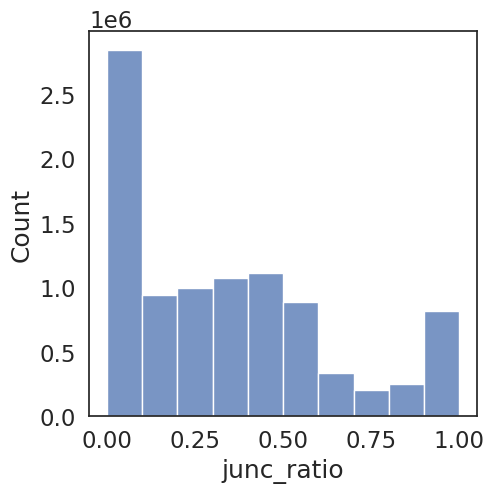

In [24]:
# update juncratio 
sim_data["clustminjunc"] = sim_data["cluster_count"] - sim_data["junc_count"]
sim_data["junc_ratio"] = sim_data["junc_count"] / sim_data["cluster_count"]

# make histogram of junc_ratio
plt.figure(figsize=(5,5))
sns.histplot(sim_data.junc_ratio, bins=10)

### Prep data for model 

In [25]:
if device == torch.device('cuda'):
    torch.set_default_tensor_type('torch.cuda.FloatTensor')

In [26]:
cell_index_tensor, junc_index_tensor, my_data = llc.make_torch_data(sim_data, **float_type)

The number of cells going into training data is:
2405
2405


/gpfs/commons/home/kisaev/Leaflet-private/src/clustering/load_cluster_data.py:47: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ../aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  ycount).to_sparse_csr()


In [27]:
clust_labels_only = cluster_labels[["Cluster", "sample_label"]].drop_duplicates()
simple_data = sim_data[["cell_id_index", "Cluster", "cell_type", "junction_id_index", "junc_ratio", "junc_count", "cluster_count"]]
# merge with clust_labels_only 
simple_data = simple_data.merge(clust_labels_only, on = ["Cluster"])
# get true PSI for each Cluster 
simple_data.head()

,cell_id_index,Cluster,cell_type,junction_id_index,junc_ratio,junc_count,cluster_count,sample_label
0,0,114,Mammary_Gland_basal_cell,0,0.000000,0.0,25.0,positive
1,1163,114,Mammary_Gland_luminal_epithelial_cell_of_mamma...,0,0.000000,0.0,21.0,positive
2,1952,114,Mammary_Gland_luminal_epithelial_cell_of_mamma...,0,0.095238,2.0,21.0,positive
3,1164,114,Mammary_Gland_luminal_epithelial_cell_of_mamma...,0,0.104167,5.0,48.0,positive
4,222,114,Mammary_Gland_basal_cell,0,0.000000,0.0,2.0,positive


In [28]:
def quick_clust_plot(clust, simple_data, num_cols=3, plot_states_arb=True):
    
    simple_data_junc = simple_data[simple_data["Cluster"] == clust]
    # make violin plot with jitter 
    print(simple_data_junc.cell_type.value_counts())
    sample_label = simple_data_junc.sample_label.unique()[0]
    
    # if plot_states_arb = True then instead of real cell types make dummy variable and use that for cell type
    if plot_states_arb:
        # get unique values in cell type and mapping to a number 
        cell_types = simple_data_junc.cell_type.unique()
        cell_type_map = dict(zip(cell_types, range(len(cell_types))))
        simple_data_junc["cell_type"] = simple_data_junc["cell_type"].map(cell_type_map)
        #make sure new values in cell_Type are string
        simple_data_junc["cell_type"] = simple_data_junc["cell_type"].astype(str)
    
    plt.figuresize=(6, 6)

    # choose three distrinct colours to use for junction_id_index hue 
    colors = sns.color_palette("husl", num_cols)

    # use colors in violinplot
    sns.violinplot(data = simple_data_junc, x = "junc_ratio", y = "cell_type", hue="junction_id_index", palette=colors)

    # make xlim -1 to 1.1
    plt.xlim(-0.2, 1.2)
    # add sample_label to title 
    plt.title(sample_label + " label for cluster:" + str(clust), fontsize=16)
    # set x axis label to "Junction Usage Ratio (PSI)"
    plt.xlabel("Junction Usage Ratio (PSI)", fontsize=20)
    plt.ylabel("Cell Type Group", fontsize=20)
    # increase x and y tick label size to 14
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    # put legend outside the plot
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=20)
    plt.show()

/scratch/ipykernel_18745/2183167184.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  simple_data_junc["cell_type"] = simple_data_junc["cell_type"].map(cell_type_map)
/scratch/ipykernel_18745/2183167184.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  simple_data_junc["cell_type"] = simple_data_junc["cell_type"].astype(str)
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before

42680
cell_type
Mammary_Gland_basal_cell                                  753
Mammary_Gland_luminal_epithelial_cell_of_mammary_gland    330
Mammary_Gland_stromal_cell                                141
Mammary_Gland_endothelial_cell                              9
Name: count, dtype: int64


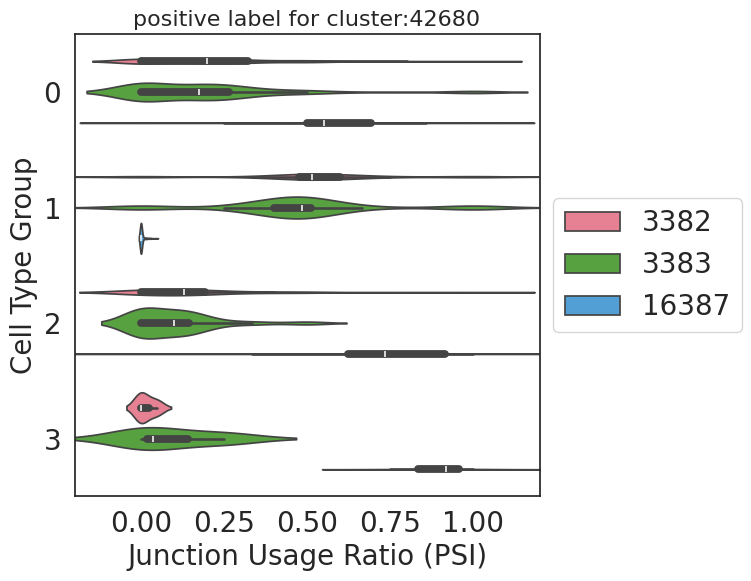

In [29]:
# let's visualize junction usage ratios for a given custer 
# sample clust from simple_data.Cluster.unique()
clust = np.random.choice(simple_data.Cluster.unique())
print(clust)
#sim.quick_clust_plot(clust, simple_data)
quick_clust_plot(clust, simple_data)

In [30]:
indices = torch.tensor(sim_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values = torch.tensor(sim_data['junc_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells = sim_data['cell_id_index'].max() + 1
num_junctions = sim_data['junction_id_index'].max() + 1
size = (num_cells, num_junctions)
# Create a sparse tensor
y_tensor = torch.sparse_coo_tensor(indices, values, size)

In [31]:
indices_counts = torch.tensor(sim_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values_counts = torch.tensor(sim_data['cluster_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells_counts = sim_data['cell_id_index'].max() + 1
num_junctions_counts = sim_data['junction_id_index'].max() + 1
size_counts = (num_cells_counts, num_junctions_counts)
# Create a sparse tensor
total_counts_tensor = torch.sparse_coo_tensor(indices_counts, values_counts, size_counts)

In [32]:
# save full dataset y_tensor and total_counts_tensor 
full_y_tensor = y_tensor
full_total_counts_tensor = total_counts_tensor

In [33]:
# remake junction counts and cluster counts sp.coo_matrix for masking analysis
indices = (sim_data.cell_id_index, sim_data.junction_id_index)
junc_counts = sp.coo_matrix((sim_data.junc_count, indices))
cluster_counts = sp.coo_matrix((sim_data.cluster_count, indices))

### Evaluate model performance when masking some of the input data

In [34]:
# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations')
import masking
from masking import *

# import reload 
from importlib import reload
reload(masking)

<module 'masking' from '/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations/masking.py'>

In [35]:
#1. get masked matrix using intron cluster counts for this mouse brain data 

# same masking percentage for all three matrices but generating three different masks
masking_percs = [0.05, 0.1, 0.2]
masks_list = []
seeds_used = []

print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
print("Getting masked matrix for each masking percentage")
print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")

for perc_mask in masking_percs:
    print("The masking percentage is: " + str(perc_mask))
    masked_matrix, seed = generate_mask(cluster_counts, mask_percentage = perc_mask, randomize_seed = True)
    seeds_used.append(seed)
    # append to masks_list
    masks_list.append(masked_matrix)

#2. get junction and intron cluster count matrices with masked values 
masked_counts = []

print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
print("Getting junction and intron cluster count matrices with masked values")
print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")

for i in range(len(masking_percs)):
    print("The masking percentage is: " + str(masking_percs[i]))
    masked_junction_counts, masked_intron_clusts = apply_mask(junc_counts, cluster_counts, masks_list[i])
    # appent masked junction and intron cluster counts to list
    masked_counts.append((masked_junction_counts, masked_intron_clusts))

#3. get input files for factor model (junction and intron cluster sparse tensor)
model_input_files = [] 

print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
print("Getting input files for factor model")
print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")

for i in range(len(masking_percs)):
    print("The masking percentage is: " + str(masking_percs[i]))
    masked_junction_counts, masked_intron_clusts = masked_counts[i]
    # get y_tensor and total_counts_tensor via prep_model_input function
    y_tensor, total_counts_tensor = prep_model_input(masked_junction_counts, masked_intron_clusts)
    # append to model_input_files list
    model_input_files.append((y_tensor, total_counts_tensor))

+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Getting masked matrix for each masking percentage
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
The masking percentage is: 0.05
The seed is:  704055
[7135437 3639705  327497 2480581 3382111 1475175 5940166 6502872 4629411
 8097072  142360 3578440 8590091 1553024 7006588 5656373 5415414 3717628
  247916 2258194 6499306 7260427  638814 5110094  743558 2700774 4860094
 5301278 2170093  798441 7439444 4138467 3031722 7779866 2810225 3754538
 2827461 6417468  930048 8592305 4456664 7129491 8970595 2599807 2788003
 2609718 5905743 2619966 3934034 2369125]
Number of entries (junction-cell pairs) masked:  479715.0
The masking percentage is: 0.1
The seed is:  973415
[2845640 9355614 8963584 6318277 3625255 6240704 5167290  542637 2390746
 5738155 1167383 4452446 7627506 4145307 2073879 7194630 9438263 8509735
 1877985 4188465 5500919 1390048 1395241 8281462  366191 1500955 6597335
  500069 5885469  486

/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations/masking.py:139: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:275.)
  indices = torch.tensor(np.nonzero(masked_intron_clusts), dtype=torch.long)


The masking percentage is: 0.1
The masking percentage is: 0.2


In [36]:
# Now can run factor model on masked data
Ks = [5, 20, 100 , 500]
all_Ks_results = {}
# Seeds used for masking 
seeds_used 

# define list of seeds for training factor model 
seeds = [42, 102, 300] #, 102]

# set concentration value to infinity 
init_conc = float('inf')

print("Learning rate seems to matter especially when K > 100, consider reducing it if running into NaN issues!")

for k in tqdm(Ks):
    
    print("------------------------------------------------")
    print("Running factor model for K = " + str(k))
    print("------------------------------------------------")
    
    # now also iterate over masking percentages 
    for i in range(len(masking_percs)):
        print("The masking percentage is: " + str(masking_percs[i]))
        print("++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
        y_tensor, total_counts_tensor = model_input_files[i]
        # run factor model
        masked_results = factor_model.main(y_tensor, total_counts_tensor, num_initializations=3, use_global_prior=True, input_conc=init_conc, K=k, seeds=seeds,loss_plot=False, num_epochs=50, lr = 0.01, save_to_file = False)
        # save results to dictionary
        all_Ks_results[(k, masking_percs[i])] = masked_results

Learning rate seems to matter especially when K > 100, consider reducing it if running into NaN issues!


  0%|          | 0/4 [00:00<?, ?it/s]

------------------------------------------------
Running factor model for K = 5
------------------------------------------------
The masking percentage is: 0.05
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Using prior for a and b per junction to model average behaviour!
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Using a fixed probability of success across all trials (infinite concentration parameter) with a binomial distribution.
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 1 with seed 42
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Elbo loss: 181322652.23356777
Epoch 40, Elbo loss: 136594257.59680858


Elbo loss: 128522513.85687509


Sample from the guide (posterior)
Extract the latent variables
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 2 with seed 102
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Elbo loss: 184362362.593143
Epoch 40, Elbo loss: 138741907.70483053


...

Sample from the guide (posterior)
Extract the latent variables
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 3 with seed 300
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Elbo loss: 183824360.20773453
Epoch 40, Elbo loss: 140517431.6624019


Elbo loss: 132665465.87749451


Sample from the guide (posterior)


100%|██████████| 4/4 [54:08<00:00, 812.14s/it] 

Extract the latent variables
All initializations complete. Returning results.
------------------------------------------------


In [37]:
print("---------------------------------------------")
print("Double check why getting this --> /gpfs/commons/home/kisaev/Leaflet-private/src/evaluations/masking.py:187: RuntimeWarning: invalid value encountered in divide")
print("---------------------------------------------")

---------------------------------------------
Double check why getting this --> /gpfs/commons/home/kisaev/Leaflet-private/src/evaluations/masking.py:187: RuntimeWarning: invalid value encountered in divide
---------------------------------------------


In [38]:
cluster_counts

<2405x19164 sparse matrix of type '<class 'numpy.float32'>'
	with 9594318 stored elements in COOrdinate format>

In [39]:
# Get pearson correlation and l1 error between true and inferred parameters (PSI)
masked_perf = []

for k in Ks:
    for perc_mask in masking_percs:
        print("Calculating performance for K = " + str(k) + " and masking percentage = " + str(perc_mask))
        masked_results = all_Ks_results[(k, perc_mask)]        
        for res in masked_results:
            # get seed that was used 
            seed = res['seed']

            # get latent variables
            psi = res['latent_vars']["psi"] # psi is the probability of a junction being used in a cluster
            assign_post=res['latent_vars']["assign"]

            # get K 
            K = psi.shape[0]
            J = psi.shape[1]

            # get scores 
            mask_matrix_used = masks_list[i]
            l1, r, l2, rmse = evaluate_model(junc_counts.toarray(), cluster_counts.toarray(), psi, assign_post, mask_matrix_used)

            # get num epochs trained for 
            nepoch = len(res["losses"])

            # save to list 
            masked_perf.append([seed, l1, r, l2, rmse, K, perc_mask, J, nepoch])

Calculating performance for K = 5 and masking percentage = 0.05


/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations/masking.py:187: RuntimeWarning: invalid value encountered in divide
  true_psi = true_juncs / true_clusts


L1 error:  0.261166
Spearman correlation:  0.25557083539530895
L2 error:  0.105435796
RMSE:  0.3247088
L1 error:  0.26229134
Spearman correlation:  0.24663106125113154
L2 error:  0.10713903
RMSE:  0.327321
L1 error:  0.26486096
Spearman correlation:  0.24417733281212856
L2 error:  0.1081924
RMSE:  0.32892612
Calculating performance for K = 5 and masking percentage = 0.1
L1 error:  0.2611822
Spearman correlation:  0.25552512562211277
L2 error:  0.10544802
RMSE:  0.32472762
L1 error:  0.2623066
Spearman correlation:  0.24659988047694095
L2 error:  0.10714698
RMSE:  0.32733312
L1 error:  0.26488134
Spearman correlation:  0.24407710597365187
L2 error:  0.10820367
RMSE:  0.32894325
Calculating performance for K = 5 and masking percentage = 0.2
L1 error:  0.26141158
Spearman correlation:  0.2543906515040767
L2 error:  0.105617955
RMSE:  0.32498917
L1 error:  0.2625089
Spearman correlation:  0.24567441970577594
L2 error:  0.10729072
RMSE:  0.32755262
L1 error:  0.26513067
Spearman correlation

In [40]:
import pandas as pd 
# make masked_perf a dataframe 
masked_perf_df = pd.DataFrame(masked_perf, columns=["seed", "l1", "r", "l2", "rmse", "K",  "perc_masked" , "J", "num_epochs"])
# get current date and time to add to file name for saving 
from datetime import datetime
now = datetime.now()
file_name = "simulated_masked_perf_df_" + now.strftime("%Y%m%d_%H%M%S")
# save to compressed csv
masked_perf_df.to_csv(file_name, compression='gzip')

### Summarize masking analysis with plots

In [41]:
masked_perf_df.head()

,seed,l1,r,l2,rmse,K,perc_masked,J,num_epochs
0,42,0.261166,0.255571,0.105436,0.324709,5,0.05,19164,50
1,102,0.262291,0.246631,0.107139,0.327321,5,0.05,19164,50
2,300,0.264861,0.244177,0.108192,0.328926,5,0.05,19164,50
3,42,0.261182,0.255525,0.105448,0.324728,5,0.10,19164,50
4,102,0.262307,0.246600,0.107147,0.327333,5,0.10,19164,50


In [42]:
# make new column combining seed and perc_masked
masked_perf_df['seed_perc_masked'] = masked_perf_df['seed'].astype(str) + "_" + masked_perf_df['perc_masked'].astype(str)
masked_perf_df.head()

# there should be 2 seperate seed_perc_masked values for each K because there were two seperate masks used 
masked_perf_df['seed_perc_masked'].value_counts()

seed_perc_masked
42_0.05     4
102_0.05    4
300_0.05    4
42_0.1      4
102_0.1     4
300_0.1     4
42_0.2      4
102_0.2     4
300_0.2     4
Name: count, dtype: int64

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


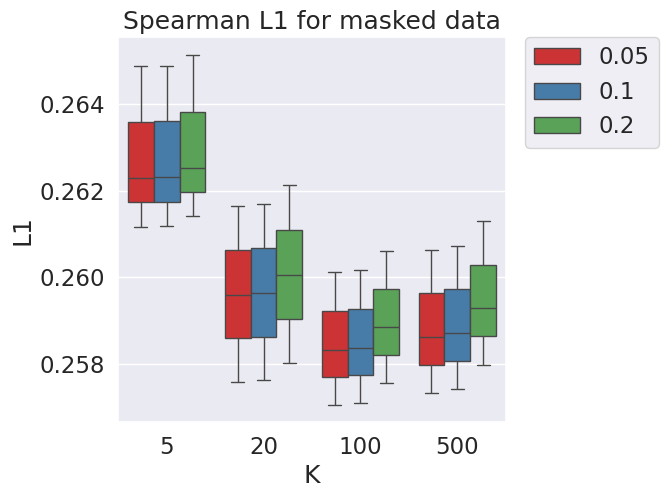

0.25706154


In [43]:
# make boxplot of l1 error for each K and masking percentage
# sns.set_style("whitegrid")
import seaborn as sns
import matplotlib.pyplot as plt 

# make boxplot for r 
sns.set_style("whitegrid")
sns.set_context("paper")
sns.set(font_scale=1.5)
plt.figure(figsize=(5, 5))

ax = sns.boxplot(x="K", y="l1", data=masked_perf_df, palette="Set1", hue="perc_masked")
ax.set_xlabel("K")
ax.set_ylabel("L1")
ax.set_title("Spearman L1 for masked data")

# put legend on the outside 
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

print(masked_perf_df.l1.min())

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


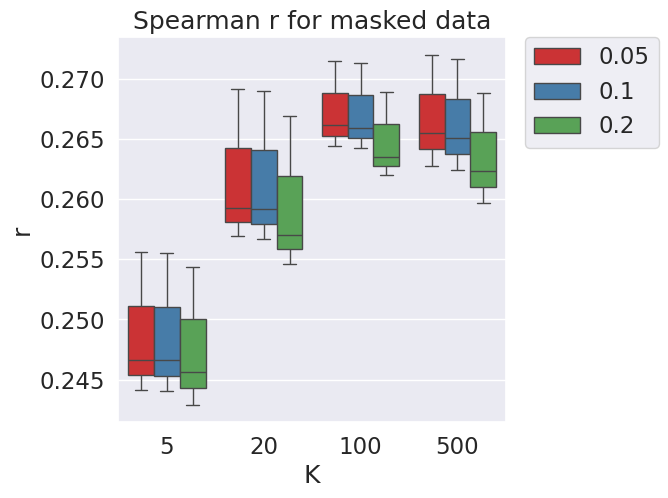

0.27200985332482425


In [44]:
# make boxplot for r 
sns.set_style("whitegrid")
sns.set_context("paper")
sns.set(font_scale=1.5)
plt.figure(figsize=(5, 5))

ax = sns.boxplot(x="K", y="r", data=masked_perf_df, palette="Set1", hue="perc_masked")
ax.set_xlabel("K")
ax.set_ylabel("r")
ax.set_title("Spearman r for masked data")
# put legend on the outside 
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()
print(masked_perf_df.r.max())

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


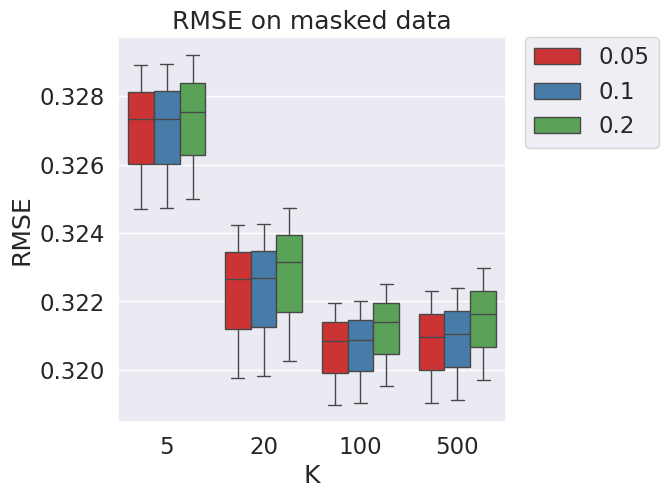

0.31898063


In [45]:
# make boxplot for rmse 
sns.set_style("whitegrid")
sns.set_context("paper")
sns.set(font_scale=1.5)
plt.figure(figsize=(5, 5))

ax = sns.boxplot(x="K", y="rmse", data=masked_perf_df, palette="Set1", hue="perc_masked")
ax.set_xlabel("K")
ax.set_ylabel("RMSE")
ax.set_title("RMSE on masked data")
# put legend on the outside 
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()
print(masked_perf_df.rmse.min())

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


K = 5
K = 20


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


K = 100
K = 500


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


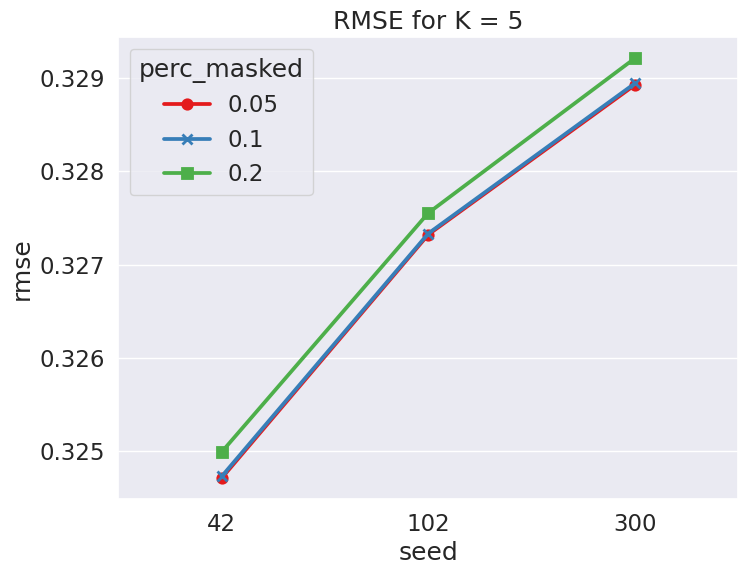

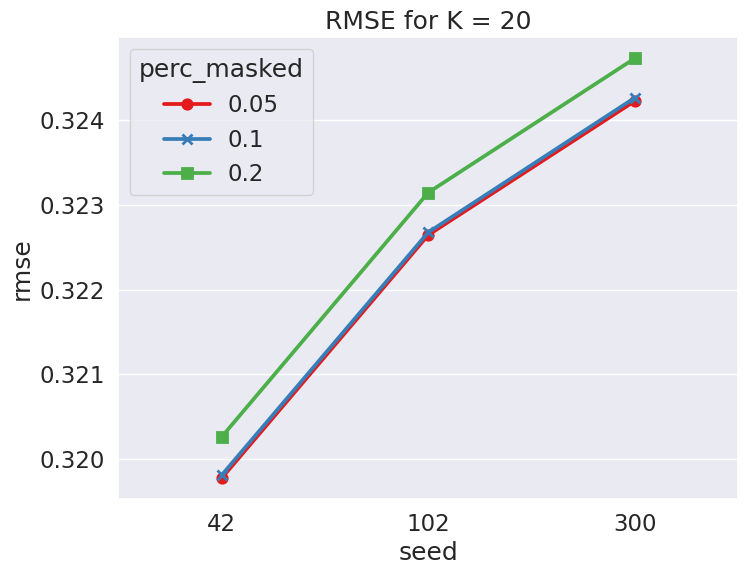

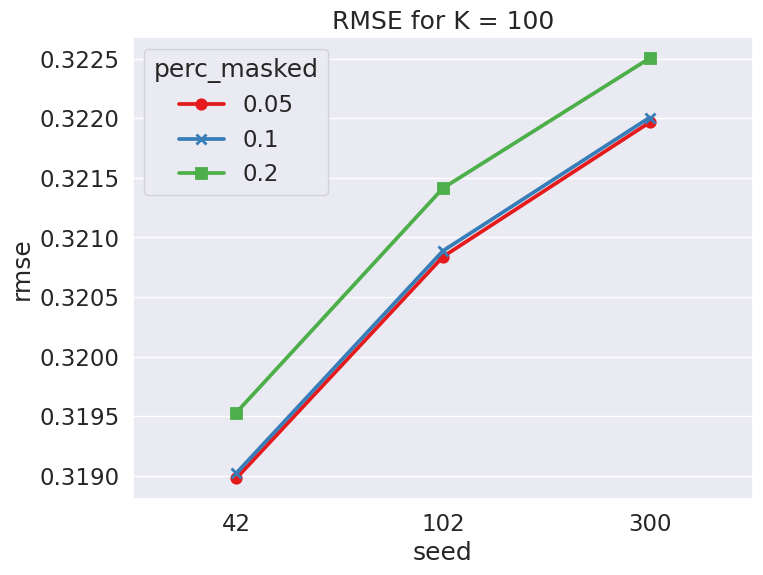

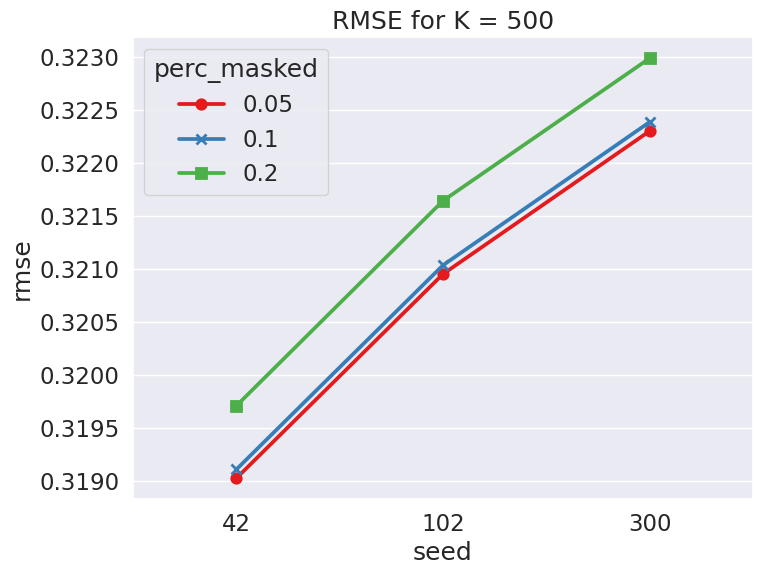

In [46]:
for k in Ks:
    print("K = " + str(k))
    just100 = masked_perf_df[masked_perf_df["K"] == k]
    # make dot plot for just100 xaxis seed, y axis is rmse, each dot shape is differed based on perc_masked
    sns.set_style("whitegrid")
    sns.set_context("paper")
    sns.set(font_scale=1.5)
    plt.figure(figsize=(8, 6))
    sns.pointplot(x="seed", y="rmse", data=just100, palette="Set1", hue="perc_masked", markers=["o", "x", "s", "D"])
    # add title for plot to be which K is shown
    plt.title("RMSE for K = " + str(k))

### Run full model

In [47]:
full_total_counts_tensor

tensor(indices=tensor([[    0,  1163,  1952,  ...,   608,  1992,   255],
                       [    0,     0,     0,  ..., 19163, 19163, 19163]]),
       values=tensor([25., 21., 21.,  ...,  3., 30.,  0.]),
       size=(2405, 19164), nnz=9594318, layout=torch.sparse_coo)

2.2.1+cu118
11.8
Using prior for a and b per junction to model average behaviour!
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Using a fixed probability of success across all trials (infinite concentration parameter) with a binomial distribution.
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 1 with seed 9793
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Elbo loss: 192622020.41939938
Epoch 40, Elbo loss: 144869615.45405403
Epoch 80, Elbo loss: 110249764.17915332


Elbo loss: 95863910.19496468


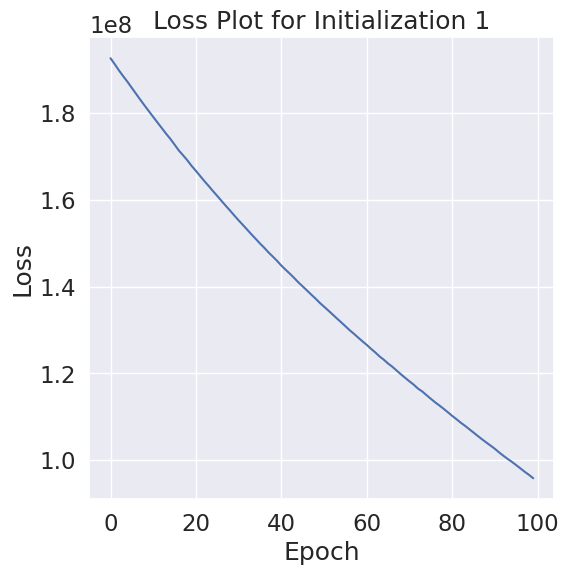

Sample from the guide (posterior)
Extract the latent variables
All initializations complete. Returning results.
------------------------------------------------


In [48]:
reload(factor_model)
best_K = 100
K = best_K
#input_conc = 50
# set input_conc to inf
input_conc = float('inf')
all_results = factor_model.main(full_y_tensor, full_total_counts_tensor, num_initializations=1, use_global_prior=True, input_conc=input_conc, K=K, lr=0.01, loss_plot=True, num_epochs=100, save_to_file = False)

In [49]:
# extract latent variables for all iterations 
latent_results = {} 
for i in range(len(all_results)):
    latent_vars = all_results[i]['latent_vars']
    pi = latent_vars["pi"] # overall contribution of each factor to cell population, one value per k
    conc = latent_vars["dir_conc"] # one scaling value 
    assign_post = latent_vars["assign"]
    psis = latent_vars["psi"] # psi is the probability of a junction being used in a cluster
    a = latent_vars["a"] 
    b = latent_vars["b"] 
    print("The inferred concentration parameter is: " + str(conc))
    print("The inferred pi parameter is: " + str(pi))
    # add all latent variables to latent_results dictionary
    latent_results[i] = {"pi": pi, "conc": conc, "assign_post": assign_post, "psis": psis, "a": a, "b": b}

The inferred concentration parameter is: 1.6726518
The inferred pi parameter is: [0.00960003 0.00962539 0.00974501 0.00955404 0.00969627 0.01018468
 0.00978069 0.01014175 0.01030407 0.00989632 0.00885887 0.00980707
 0.00937123 0.01060396 0.01001993 0.01144946 0.0100716  0.01026846
 0.01039032 0.01090871 0.01106712 0.01160858 0.00959091 0.00974373
 0.00956872 0.00959197 0.01159322 0.01008861 0.01030443 0.00981066
 0.01059732 0.01038765 0.00876678 0.00938817 0.00922293 0.01109107
 0.01044052 0.01023257 0.0095041  0.01012135 0.00952182 0.01075603
 0.00847822 0.00989935 0.01128923 0.00947291 0.00849822 0.00913762
 0.01021445 0.01002086 0.00923332 0.0103705  0.01143452 0.00964109
 0.0099223  0.00907887 0.00999698 0.01068599 0.01000371 0.00973028
 0.00898996 0.00884095 0.01002794 0.00980235 0.01018208 0.01022823
 0.01117895 0.00919682 0.01002167 0.01051416 0.01050851 0.00880398
 0.01000124 0.01026528 0.00953884 0.00973666 0.01029727 0.01040079
 0.01012535 0.01037294 0.00910211 0.01047493 0.0

In [50]:
cell_types_id = sim_data[["cell_id", "cell_id_index", "new_cell_type"]].drop_duplicates()
# reorder by cell_id_index
cell_types_id = cell_types_id.sort_values(by = ["cell_id_index"])
cell_types_id.head()

,cell_id,cell_id_index,new_cell_type
0,A1-B000167-3_56_F-1-1_Mammary_Gland_basal_cell,0,0
1886,A10-B000166-3_56_F-1-1_Mammary_Gland_basal_cell,1,0
690,A10-B002433-3_38_F-1-1_Mammary_Gland_basal_cell,2,0
652,A10-B002435-3_39_F-1-1_Mammary_Gland_basal_cell,3,0
1877,A10-B002436-3_39_F-1-1_Mammary_Gland_basal_cell,4,0


In [51]:
cell_types_id.new_cell_type.value_counts()

new_cell_type
0    1340
2     578
3     440
1      47
Name: count, dtype: int64

In [52]:
# from dictionary of latent variables, get the assign_post for each iteration and add to a dataframe
assign_post = []
for i in range(len(latent_results)):
    assign_post_df = pd.DataFrame(latent_results[i]["assign_post"])
    assign_post_df["new_cell_type"] = cell_types_id.new_cell_type.values
    print(assign_post_df.new_cell_type.value_counts())
    assign_post.append(latent_results[i]["assign_post"])

new_cell_type
0    1340
2     578
3     440
1      47
Name: count, dtype: int64


In [53]:
assign_post_df.shape

(2405, 101)

### Evaluate latent factor space

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


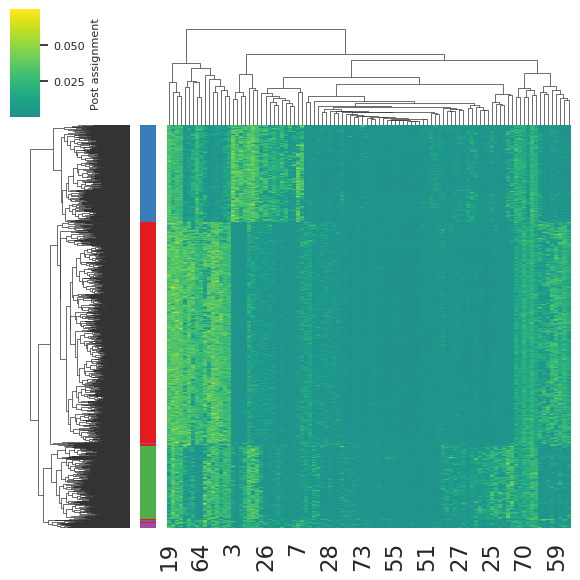

In [54]:
import seaborn as sns

color_palette = sns.color_palette("Set1", n_colors=len(cell_types_id['new_cell_type'].unique()))
# Create a color bar legend
legend = sns.color_palette(palette=color_palette, as_cmap=True)

# Obtain cell type labels for every cell in the matrix also 
unique_cell_types = cell_types_id['new_cell_type'].unique()
num_unique_types = len(unique_cell_types)
colors = sns.color_palette('Set1', n_colors=num_unique_types)  # You can use any color palette
cell_types = cell_types_id.new_cell_type.values

# create colours for each cell type 
cell_type_colors = {new_cell_type: color for new_cell_type, color in zip(unique_cell_types, colors)}
row_colors = [cell_type_colors[new_cell_type] for new_cell_type in cell_types]

for i in range(len(assign_post)):
    cluster = sns.clustermap(
        data=assign_post[i],
        method='complete',
        cmap="viridis",
        annot=False,
        fmt=".2f",
        yticklabels=False,
        figsize=(6, 6),
        center=0,
        row_colors=row_colors,  # Apply row colors
        cbar_kws={'label': 'Post assignment'} 
        )
    cluster.cax.set_ylabel('Post assignment', size=8)
    # add title 
    #cluster.ax_heatmap.set_title('Posterior assignment probabilities for iteration number ' + str(i))
    # Increase font size for color bar tick labels:
    cbar_ax = cluster.cax
    for label in cbar_ax.yaxis.get_ticklabels():
        label.set_size(8)

In [55]:
from umap.umap_ import UMAP
reducer = UMAP()

In [56]:
umaps = []

for i in range(len(assign_post)):
    print("Running UMAP for iteration number " + str(i))
    # make UMAP using average assign_post across seeds and color points by cell_type 
    embedding = reducer.fit_transform(assign_post[i])
    umaps.append(embedding)

Running UMAP for iteration number 0


In [57]:
# make function for plotting UMAPs 
def umap_plot(umap, cell_type_colors, cell_types):
    sns.set_style("whitegrid")
    sns.set_context("paper")
    plt.figure(figsize=(4, 4))    
    plt.scatter(umap[:, 0], umap[:, 1],
        c=[cell_type_colors[cell_type] for cell_type in cell_types],
        s=8, alpha=0.3)
    # xlab 
    plt.xlabel("UMAP 1")
    # ylab
    plt.ylabel("UMAP 2")

In [58]:
len(assign_post)

1

Plotting UMAP for iteration number 0


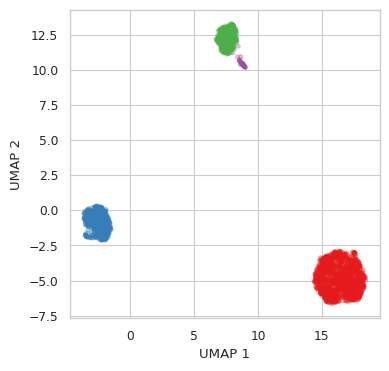

In [59]:
for i in range(len(umaps)):
    print("Plotting UMAP for iteration number " + str(i))
    umap_plot(umaps[i], cell_type_colors, cell_types)

Text(0, 0.5, 'Number of cells')

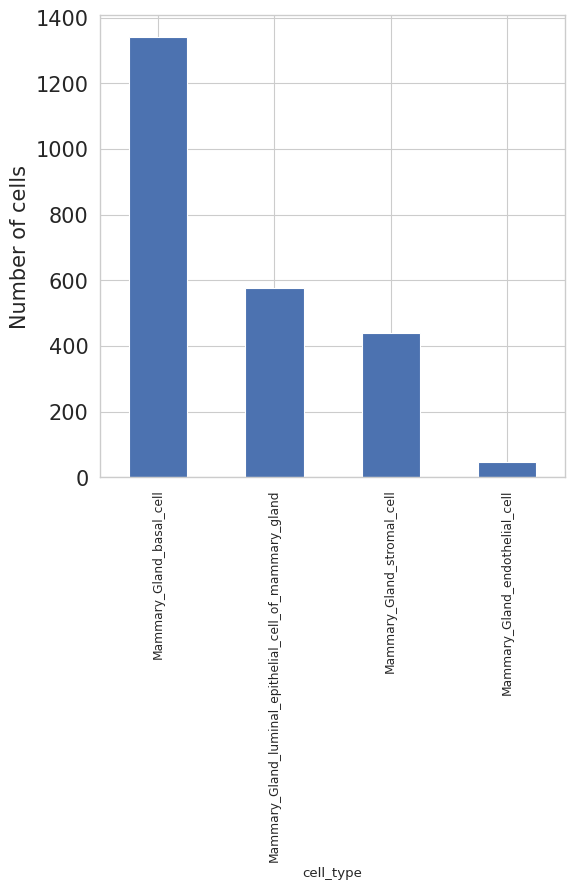

In [60]:
# make a histogram of number of cells in each cell type in cell_ids_conversion
cell_ids_conversion.cell_type.value_counts().plot(kind='bar') 

# increase font of y-axis labels and ticks 
plt.yticks(fontsize=15)
plt.ylabel("Number of cells", fontsize=15)

          pi    factor iteration
21  0.011609  Factor21         0
26  0.011593  Factor26         0
15  0.011449  Factor15         0
52  0.011435  Factor52         0
44  0.011289  Factor44         0
66  0.011179  Factor66         0
89  0.011178  Factor89         0
35  0.011091  Factor35         0
20  0.011067  Factor20         0
19  0.010909  Factor19         0
87  0.010763  Factor87         0
41  0.010756  Factor41         0
90  0.010722  Factor90         0
84  0.010717  Factor84         0
57  0.010686  Factor57         0
97  0.010677  Factor97         0
83  0.010672  Factor83         0
13  0.010604  Factor13         0
30  0.010597  Factor30         0
94  0.010572  Factor94         0
69  0.010514  Factor69         0
70  0.010509  Factor70         0
81  0.010475  Factor81         0
36  0.010441  Factor36         0
96  0.010434  Factor96         0
77  0.010401  Factor77         0
18  0.010390  Factor18         0
31  0.010388  Factor31         0
82  0.010381  Factor82         0
79  0.0103

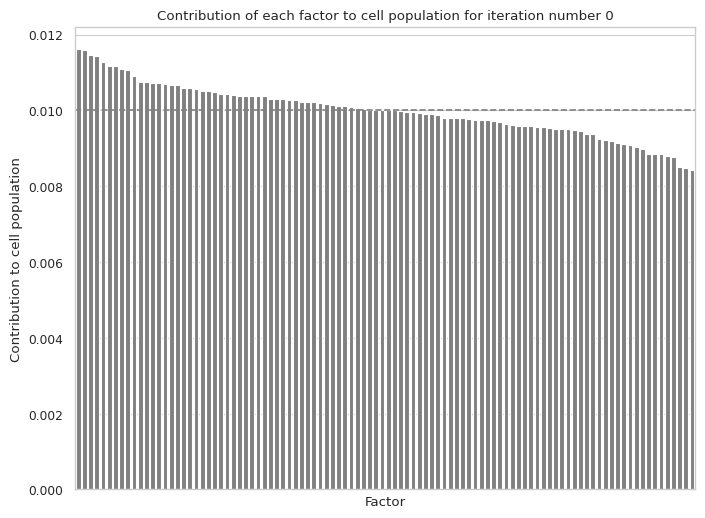

In [61]:
# loop through all restults and make barplot of contribute of each factor to cell population pi

for i in range(len(latent_results)):
    pi = latent_results[i]["pi"]
    pi_df = pd.DataFrame(pi, columns = ["pi"])
    pi_df["factor"] = "Factor" + pi_df.index.astype(str)
    pi_df["iteration"] = i
    pi_df["iteration"] = pi_df["iteration"].astype(str)
    pi_df["factor"] = pi_df["factor"].astype(str)
    pi_df["pi"] = pi_df["pi"].astype(float)
    # order by pi
    pi_df = pi_df.sort_values(by = ["pi"], ascending = False)
    # prnt the factors with contribution greater than 0.01
    print(pi_df[pi_df["pi"] > 0.01])    
    # make barplot
    sns.set_style("whitegrid")
    sns.set_context("paper")
    plt.figure(figsize=(8, 6))
    ax = sns.barplot(x="factor", y="pi", data=pi_df, color="grey") #, palette="Set1")
    # draw a line at 0.01 
    ax.axhline(0.01, color='grey', linestyle='--')
    ax.set_xlabel("Factor")
    # remove xaxis ticks 
    ax.set_xticks([])
    ax.set_ylabel("Contribution to cell population")
    ax.set_title("Contribution of each factor to cell population for iteration number " + str(i))
    plt.show()

In [62]:
print("When concentration is lower, contribution to cell population is higher for a smaller number of factors")

When concentration is lower, contribution to cell population is higher for a smaller number of factors


In [63]:
# average junction behaviour of 0.4 means that given 100 reads, this junction will likely get 40 reads

can make simulation more hierarchical first sample psi_o ~ beta(0.5, 0.5) and psi_c for each cell type 

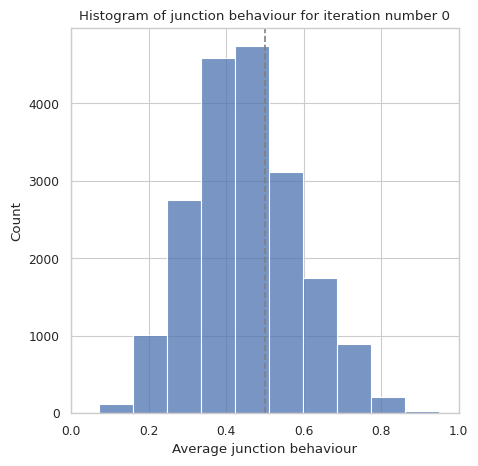

In [64]:
# get average junction behaviour 
for i in range(len(latent_results)):
    junc_beh = latent_results[i]["a"] / (latent_results[i]["a"] + latent_results[i]["b"])
    junc_beh_df = pd.DataFrame(junc_beh, columns = ["junction_beh"])
    junc_beh_df["junction_id_index"] = junc_beh_df.index
    junc_beh_df["iteration"] = i
    # make a histogram of junction behaviour
    sns.set_style("whitegrid")
    sns.set_context("paper")
    plt.figure(figsize=(5, 5))
    sns.histplot(junc_beh_df.junction_beh, bins=10)
    # make xaxis 0 to 1 
    plt.xlim(0, 1)
    plt.xlabel("Average junction behaviour")
    # draw a line a 0.5 
    plt.axvline(0.5, color='grey', linestyle='--')
    plt.title("Histogram of junction behaviour for iteration number " + str(i))
    plt.show()

In [65]:
# now let's look at psis 
psis = latent_results[0]["psis"]
psis.shape # K by J 

# rotate so it's J by K
psis = psis.T

# now convert to dataframe
psis_df = pd.DataFrame(psis)
psis_df["junction_id_index"] = psis_df.index

# calculate junction standard deviation across the K factors 
psis_df["std"] = psis_df[psis_df.columns[0:K]].std(axis=1)

# sort by std
psis_df = psis_df.sort_values(by = ["std"], ascending = False)
psis_df.head()

,0,1,2,3,4,5,6,7,8,9,...,92,93,94,95,96,97,98,99,junction_id_index,std
14961,0.668876,0.813275,0.130867,0.306418,0.730730,0.938534,0.910696,0.113059,0.241084,0.175976,...,0.105102,0.268013,0.750107,0.582223,0.128338,0.065026,0.566570,0.182519,14961,0.274054
13398,0.388251,0.687871,0.194164,0.241121,0.258462,0.837561,0.941199,0.425187,0.215172,0.262862,...,0.159512,0.320296,0.801454,0.783700,0.320668,0.187385,0.660871,0.907117,13398,0.271746
17276,0.503571,0.711976,0.214091,0.236391,0.320527,0.601508,0.915759,0.062895,0.324629,0.323615,...,0.279574,0.110679,0.715735,0.851282,0.266120,0.171355,0.529738,0.856685,17276,0.266477
14155,0.772861,0.813966,0.066020,0.665673,0.191713,0.859089,0.534739,0.417496,0.444289,0.355807,...,0.109501,0.109686,0.649029,0.711657,0.077737,0.384463,0.741057,0.845762,14155,0.264747
18589,0.874495,0.486822,0.287199,0.330400,0.200902,0.928619,0.646231,0.763220,0.262549,0.123890,...,0.308346,0.503026,0.838949,0.824537,0.535899,0.190985,0.483818,0.760124,18589,0.263629


<Figure size 600x600 with 0 Axes>

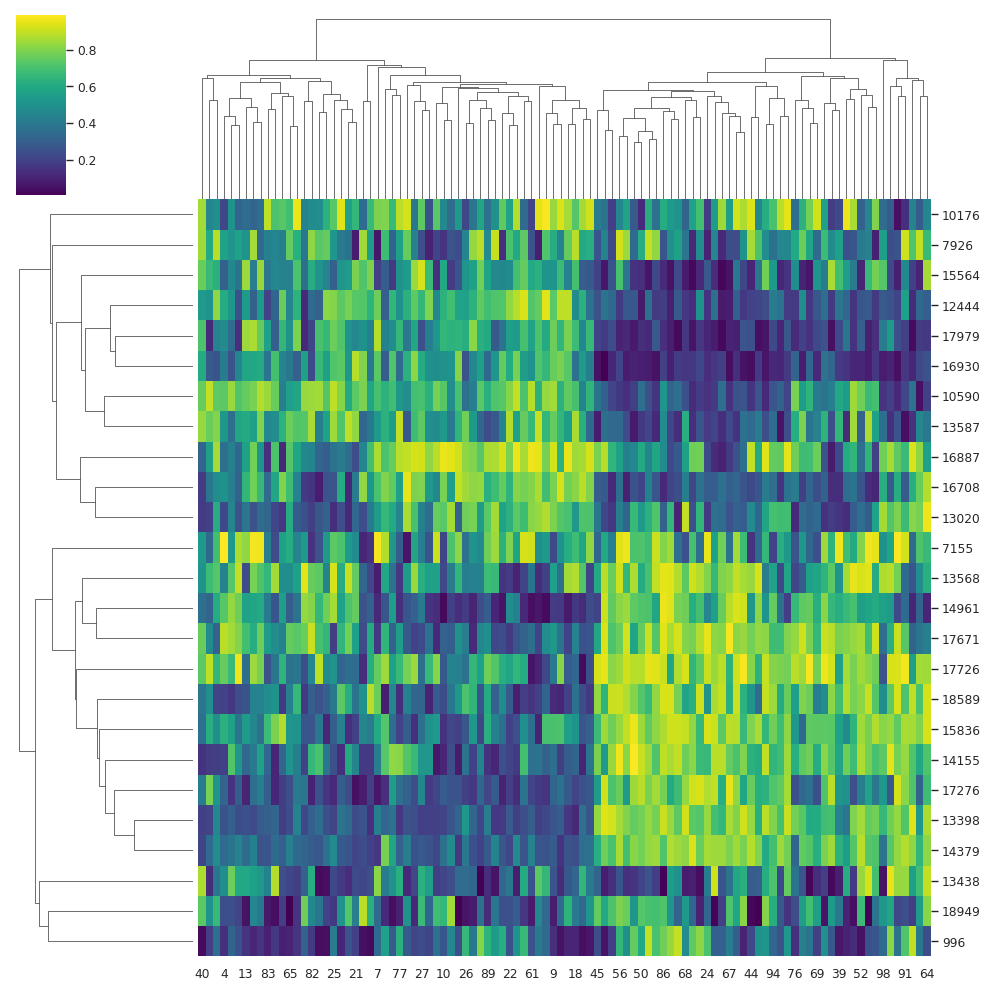

In [66]:
# make a heatmap of psis for the top 5 junctions across factors
sns.set_style("whitegrid")
sns.set_context("paper")
plt.figure(figsize=(6, 6))
ax = sns.clustermap(psis_df[psis_df.columns[0:K]].iloc[0:25], cmap="viridis")

In [67]:
reload(factor_model)

2.2.1+cu118
11.8


<module 'factor_model' from '/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor/factor_model.py'>

In [68]:
# evaluate overall likelihood of the model given observed data
res = latent_results[0]
pred = torch.mm(torch.tensor(res["assign_post"]), torch.tensor(res["psis"]))
input_conc = factor_model.convertr(input_conc, "bb_conc")
print(input_conc)
# make sure everything is on cpu going into my_log_prob
pred = pred.cpu()
input_conc = input_conc.cpu()
binom_loglik = factor_model.my_log_prob(full_y_tensor.cpu(), full_total_counts_tensor.cpu(), pred, input_conc)
print("The binomial log likelihood is: " + str(binom_loglik))

tensor(inf)
The binomial log likelihood is: tensor(-90720960.)


K set to 100
- When input_conc is 0.5, bbinomial log lik = -29761240
- When input_conc is 1, bbinomial log lik = -26627368
- When input conc is 2, bbinomial log lik = -24241776
- When input conc is 50, bbinomial log lik = -25973144
- When input conc is inf, bbinomial log lik = -16072950

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/scratch/ipykernel_18745/3413789592.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=axislabs, y=data_vals, palette="Set1")
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Text(0, 0.5, 'Negative log likelihood')

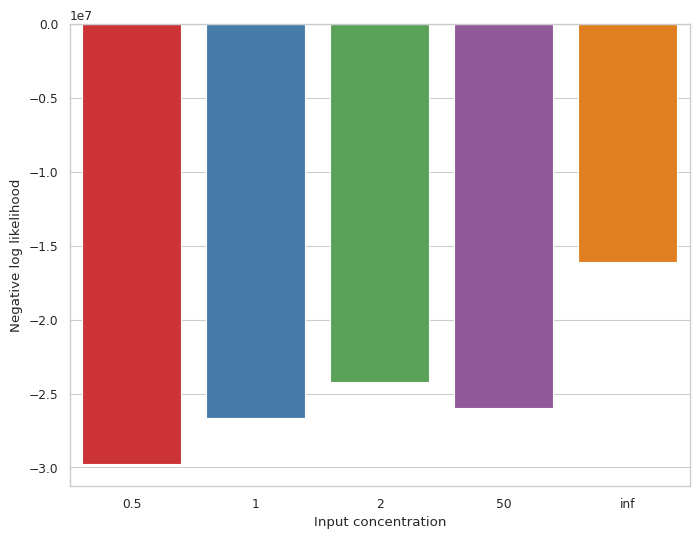

In [69]:
# make a barplot of these values -29882312 -26755432 -24128212 -17080404 -15896266 where xaxis is input_conc, 0.5,1,2,50,inf
data_vals = [-29761240, -26627368, -24241776, -25973144, -16072950]
axislabs = ["0.5", "1", "2", "50", "inf"]
sns.set_style("whitegrid")
sns.set_context("paper")
plt.figure(figsize=(8, 6))
ax = sns.barplot(x=axislabs, y=data_vals, palette="Set1")
ax.set_xlabel("Input concentration")
# y axis is negative log likelihood
ax.set_ylabel("Negative log likelihood")

### Take model with K=100 and prune the very lowly used factors. Re-calculate performance metrics (1) without re-normalizing pi vector and (2) with normalizing pi vector

In [70]:
# extract latent variables for all iterations 
latent_results = {} 
for i in range(len(all_results)):
    latent_vars = all_results[i]['latent_vars']
    pi = latent_vars["pi"] # overall contribution of each factor to cell population, one value per k
    conc = latent_vars["dir_conc"] # one scaling value 
    assign_post = latent_vars["assign"]
    psis = latent_vars["psi"] # psi is the probability of a junction being used in a cluster
    a = latent_vars["a"] 
    b = latent_vars["b"] 
    print("The inferred concentration parameter is: " + str(conc))
    print("The inferred pi parameter is: " + str(pi))
    # add all latent variables to latent_results dictionary
    latent_results[i] = {"pi": pi, "conc": conc, "assign_post": assign_post, "psis": psis, "a": a, "b": b}

The inferred concentration parameter is: 1.6726518
The inferred pi parameter is: [0.00960003 0.00962539 0.00974501 0.00955404 0.00969627 0.01018468
 0.00978069 0.01014175 0.01030407 0.00989632 0.00885887 0.00980707
 0.00937123 0.01060396 0.01001993 0.01144946 0.0100716  0.01026846
 0.01039032 0.01090871 0.01106712 0.01160858 0.00959091 0.00974373
 0.00956872 0.00959197 0.01159322 0.01008861 0.01030443 0.00981066
 0.01059732 0.01038765 0.00876678 0.00938817 0.00922293 0.01109107
 0.01044052 0.01023257 0.0095041  0.01012135 0.00952182 0.01075603
 0.00847822 0.00989935 0.01128923 0.00947291 0.00849822 0.00913762
 0.01021445 0.01002086 0.00923332 0.0103705  0.01143452 0.00964109
 0.0099223  0.00907887 0.00999698 0.01068599 0.01000371 0.00973028
 0.00898996 0.00884095 0.01002794 0.00980235 0.01018208 0.01022823
 0.01117895 0.00919682 0.01002167 0.01051416 0.01050851 0.00880398
 0.01000124 0.01026528 0.00953884 0.00973666 0.01029727 0.01040079
 0.01012535 0.01037294 0.00910211 0.01047493 0.0

In [71]:
# iterate through all results and evaluate pi from latent variables, remove pi values that are less than 0.01

pruned_latent_results = []

for i in range(len(latent_results)):
    pi = latent_results[i]["pi"]
    
    # identify factors with pi less than 0.01
    pi_less_001 = np.where(pi < 0.01)
    
    # remove these factors from pi
    pi = np.delete(pi, pi_less_001)

    # remove these factors from psis
    psis = latent_results[i]["psis"]
    psis = np.delete(psis, pi_less_001, axis=0)

    # remove these factors from assign_post
    assign_post = latent_results[i]["assign_post"]
    assign_post = np.delete(assign_post, pi_less_001, axis=1)
    
    # also save a, b and conc 
    a = latent_results[i]["a"]
    b = latent_results[i]["b"]
    conc = latent_results[i]["conc"]

    print("The final number of factors is: " + str(len(pi)))
    # add to pruned_latent_results
    pruned_latent_results.append({"pi": pi, "conc": conc, "assign_post": assign_post, "psis": psis, "a": a, "b": b})

The final number of factors is: 52


In [72]:
# from dictionary of latent variables, get the assign_post for each iteration and add to a dataframe
assign_post = []
for i in range(len(pruned_latent_results)):
    assign_post_df = pd.DataFrame(pruned_latent_results[i]["assign_post"])
    assign_post_df["new_cell_type"] = cell_types_id.new_cell_type.values
    print(assign_post_df.new_cell_type.value_counts())
    assign_post.append(pruned_latent_results[i]["assign_post"])

new_cell_type
0    1340
2     578
3     440
1      47
Name: count, dtype: int64


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


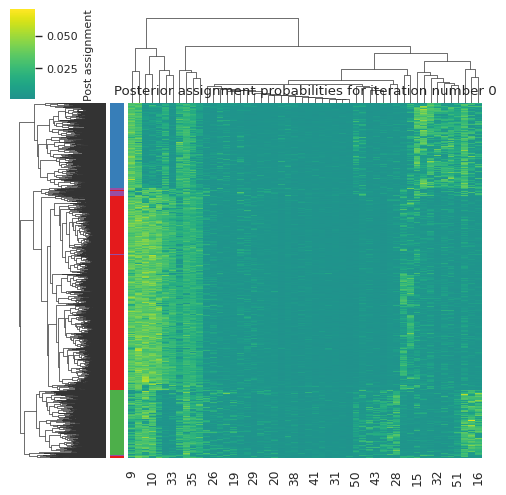

In [73]:
color_palette = sns.color_palette("Set1", n_colors=len(cell_types_id['new_cell_type'].unique()))
# Create a color bar legend
legend = sns.color_palette(palette=color_palette, as_cmap=True)

# Obtain cell type labels for every cell in the matrix also 
unique_cell_types = cell_types_id['new_cell_type'].unique()
num_unique_types = len(unique_cell_types)
colors = sns.color_palette('Set1', n_colors=num_unique_types)  # You can use any color palette
cell_types = cell_types_id.new_cell_type.values

# create colours for each cell type 
cell_type_colors = {new_cell_type: color for new_cell_type, color in zip(unique_cell_types, colors)}
row_colors = [cell_type_colors[new_cell_type] for new_cell_type in cell_types]

for i in range(len(assign_post)):
    cluster = sns.clustermap(
        data=assign_post[i],
        method='complete',
        cmap="viridis",
        annot=False,
        fmt=".2f",
        yticklabels=False,
        figsize=(5, 5),
        center=0,
        row_colors=row_colors,  # Apply row colors
        cbar_kws={'label': 'Post assignment'} 
        )
    cluster.cax.set_ylabel('Post assignment', size=8)
    # add title 
    cluster.ax_heatmap.set_title('Posterior assignment probabilities for iteration number ' + str(i))
    # Increase font size for color bar tick labels:
    cbar_ax = cluster.cax
    for label in cbar_ax.yaxis.get_ticklabels():
        label.set_size(8)

In [74]:
print(Ks)
print(seeds_used)
print(seeds)

[5, 20, 100, 500]
[704055, 973415, 855139]
[42, 102, 300]


In [75]:
# evaluate pruned models on masking tasks 
# Now can run factor model on masked data
all_Ks_results = {}
masked_perf_w_pruning = []

# set input_conc to inf 
input_conc = float('inf') 

for k in Ks:
    
    print("------------------------------------------------")
    print("Running factor model for K = " + str(k))
    print("------------------------------------------------")
    
    # now also iterate over masking percentages 
    for i in range(len(masking_percs)):
        
        print("The masking percentage is: " + str(masking_percs[i]))
        y_tensor, total_counts_tensor = model_input_files[i]
        # run factor model
        masked_results = factor_model.main(y_tensor, total_counts_tensor, num_initializations=3, use_global_prior=True, input_conc=input_conc, K=k, seeds=seeds,loss_plot=False, num_epochs=100, lr = 0.01, save_to_file = False)
        # prune the results based on pi to only keep factors with pi > 0.01 and evaluate the model 

        for res in masked_results:
            # get seed that was used 
            seed = res['seed']

            # get latent variables
            psi = res['latent_vars']["psi"] # psi is the probability of a junction being used in a cluster
            assign_post=res['latent_vars']["assign"]
            pi = res['latent_vars']["pi"]

            # get max usage across cells for each factor via assign_post
            max_usage = np.max(assign_post, axis=0)
            print("The max usage across cells for each factor is: " + str(max_usage))

            # let's prune the results based on max_usage to only keep factors with max_usage > 0.01
            max_usage_less_001 = np.where(max_usage < 0.01)
            print(psi.shape)
            psi = np.delete(psi, max_usage_less_001, axis=0)
            print(psi.shape)
            print(assign_post.shape)
            assign_post = np.delete(assign_post, max_usage_less_001, axis=1)
            print(assign_post.shape)
            
            pi = np.delete(pi, max_usage_less_001)
            
            print("The number of factors after pruning is: " + str(len(pi)))
            new_K = len(pi)

            # if new_K is empty of nan replace with 0
            if np.isnan(new_K):
                new_K = 0
            
            old_k = k 

            # get K 
            K = psi.shape[0]
            J = psi.shape[1]

            # get scores 
            mask_matrix_used = masks_list[i]
            l1, r, l2, rmse = evaluate_model(junc_counts.toarray(), cluster_counts.toarray(), psi, assign_post, mask_matrix_used)

            # get num epochs trained for 
            nepoch = len(res["losses"])

            # save to list 
            masked_perf.append([seed, l1, r, l2, rmse, old_k, new_K, masking_percs[i], J, nepoch])

------------------------------------------------
Running factor model for K = 5
------------------------------------------------
The masking percentage is: 0.05
Using prior for a and b per junction to model average behaviour!
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Using a fixed probability of success across all trials (infinite concentration parameter) with a binomial distribution.
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 1 with seed 42
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Elbo loss: 181322652.23356777
Epoch 40, Elbo loss: 136594257.59680858
Epoch 80, Elbo loss: 105848323.43027183


Elbo loss: 94643153.70023803


Sample from the guide (posterior)
Extract the latent variables
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 2 with seed 102
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Elbo loss: 184362362.593143
Epoch 40, Elbo loss: 138741907.70483053
Epoch 80, Elbo loss: 107428908.87313995


Elbo loss: 95839581.00237298


Sample from the guide (posterior)
Extract the latent variables
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 3 with seed 300
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Elbo loss: 186342129.06023383
Epoch 40, Elbo loss: 140722347.92360586
Epoch 80, Elbo loss: 108991602.65642211


...

Sample from the guide (posterior)
Extract the latent variables
All initializations complete. Returning results.
------------------------------------------------
The max usage across cells for each factor is: [0.44965187 0.43248048 0.4186685  0.33729616 0.37055615]
(5, 19164)
(5, 19164)
(2405, 5)
(2405, 5)
The number of factors after pruning is: 5
L1 error:  0.21410073
Spearman correlation:  0.46448004839731577
L2 error:  0.07528825
RMSE:  0.27438703
The max usage across cells for each factor is: [0.35335952 0.42366418 0.36392564 0.4745386  0.30341148]
(5, 19164)
(5, 19164)
(2405, 5)
(2405, 5)
The number of factors after pruning is: 5
L1 error:  0.21485418
Spearman correlation:  0.45205152052934705
L2 error:  0.0764025
RMSE:  0.27641
The max usage across cells for each factor is: [0.46586505 0.36422238 0.45388675 0.3146237  0.41110304]
(5, 19164)
(5, 19164)
(2405, 5)
(2405, 5)
The number of factors after pruning is: 5
L1 error:  0.21697235
Spearman correlation:  0.4558678904488414
L2 er

Elbo loss: 79576955.8695217


Sample from the guide (posterior)
Extract the latent variables
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 2 with seed 102
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Elbo loss: 154925208.4470455
Epoch 40, Elbo loss: 116554107.17513984
Epoch 80, Elbo loss: 90269911.82889721


Elbo loss: 80570630.76658972


Sample from the guide (posterior)
Extract the latent variables
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 3 with seed 300
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Elbo loss: 156588213.7785033
Epoch 40, Elbo loss: 118212286.01808819
Epoch 80, Elbo loss: 91584207.67781273


In [ ]:
masked_perf_df = pd.DataFrame(masked_perf, columns=["seed", "l1", "r", "l2", "rmse", "old_k", "K",  "perc_masked" , "J", "num_epochs"])
masked_perf_df.tail()

In [ ]:
masked_perf_df[masked_perf_df["old_k"] == 100]

In [ ]:
masked_perf_df.rmse.unique().min()

In [ ]:
# make scatterplot of old_k vs new_K for each masking percentage and colour by rmse 
sns.set_style("whitegrid")
sns.set_context("paper")
sns.set(font_scale=1.5)
plt.figure(figsize=(8, 6))
ax = sns.scatterplot(x="old_k", y="K", data=masked_perf_df, hue="rmse", palette="viridis")
# make rmse color continous 
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1)
ax.set_xlabel("Old K")
ax.set_ylabel("New K")
ax.set_title("Old K vs New K for each masking percentage")
plt.show()

In [ ]:
# fit with 100 factors and then prune and get 20 factors, expect to get better metrics than just K=20 factors 
# can also re-normalize the pi vector after prunning 